# Partie 1 - Test des descripteurs sans IA 
1. HOG, descripteur de forme globale
2. SIFT et ORB, descripteur de points locaux

**Justification :**

On évite les descripteurs de couleurs car ca n'a pas de réel sens de comparer des voitures sur leur couleur.

Même raisonnement pour les descripteurs de textures, cela n'a pas de sens pour comparer différentes voitures.

Pour ce qui est de HOG, SIFT et ORB, ce sont des descripteurs qui pourront surement capter les spécificités des marques/modèles. 

## 1.1 Implémentation de HOG (Histogram of Oriented Gradients)
Nous allons extraire les caractéristiques de forme. Les images sont redimensionnées en 128x128 et converties en niveaux de gris pour uniformiser la taille du descripteur.

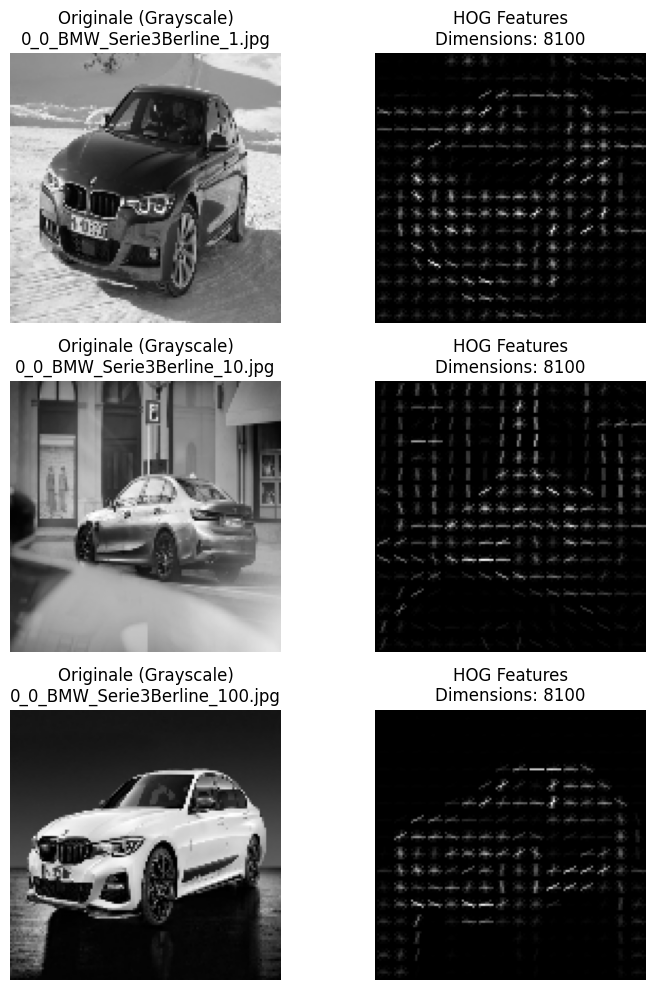

In [1]:
import os
import cv2
import time
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import hog
from sklearn.metrics.pairwise import cosine_similarity

DATA_DIR = "../data/raw/Cars"
all_images = [f for f in os.listdir(DATA_DIR) if f.endswith(('.jpg', '.jpeg', '.png'))]

def extract_hog_features(img_path, target_size=(128, 128), visualize=False):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None: return None
    
    img_resized = cv2.resize(img, target_size)
    
    if visualize:
        features, hog_image = hog(img_resized, orientations=9, pixels_per_cell=(8, 8),
                                  cells_per_block=(2, 2), visualize=True)
        return features, hog_image, img_resized
    else:
        features = hog(img_resized, orientations=9, pixels_per_cell=(8, 8),
                       cells_per_block=(2, 2), visualize=False)
        return features

fig, axes = plt.subplots(3, 2, figsize=(8, 10))
for i in range(3):
    img_path = os.path.join(DATA_DIR, all_images[i])
    features, hog_img, img_res = extract_hog_features(img_path, visualize=True)
    
    axes[i, 0].imshow(img_res, cmap='gray')
    axes[i, 0].set_title(f"Originale (Grayscale)\n{all_images[i]}")
    axes[i, 0].axis('off')
    
    axes[i, 1].imshow(hog_img, cmap='gray')
    axes[i, 1].set_title(f"HOG Features\nDimensions: {features.shape[0]}")
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()

In [2]:
print(f"Début de l'indexation HOG pour {len(all_images)} images...")

db_features = []
db_paths = []
db_classes = []

start_index_time = time.time()

for img_name in all_images:
    img_path = os.path.join(DATA_DIR, img_name)
    feat = extract_hog_features(img_path)
    
    if feat is not None:
        db_features.append(feat)
        db_paths.append(img_path)
        
        parts = img_name.split('_')
        db_classes.append(f"{parts[0]}_{parts[1]}")

end_index_time = time.time()

db_features = np.array(db_features)
db_paths = np.array(db_paths)
db_classes = np.array(db_classes)

indexing_time = end_index_time - start_index_time
descriptor_size_mb = db_features.nbytes / (1024 * 1024)

print("-" * 40)
print(f"Temps total d'indexation : {indexing_time:.2f} secondes")
print(f"Taille de la base de descripteurs : {descriptor_size_mb:.2f} MB")
print(f"Dimension d'un descripteur HOG : {db_features.shape[1]}")
print("-" * 40)

Début de l'indexation HOG pour 10000 images...
----------------------------------------
Temps total d'indexation : 68.03 secondes
Taille de la base de descripteurs : 617.98 MB
Dimension d'un descripteur HOG : 8100
----------------------------------------


In [3]:
def evaluate_query(retrieved_labels, query_label, total_relevant, k):
    retrieved_k = retrieved_labels[:k]
    
    relevance = [1 if label == query_label else 0 for label in retrieved_k]
    
    relevant_retrieved = sum(relevance)
    
    precision = relevant_retrieved / k
    
    recall = relevant_retrieved / total_relevant if total_relevant > 0 else 0
    
    ap = 0.0
    relevant_count = 0
    for i, rel in enumerate(relevance):
        if rel == 1:
            relevant_count += 1
            ap += relevant_count / (i + 1)
            
    if relevant_count > 0:
        ap = ap / min(total_relevant, k) 
    else:
        ap = 0.0
        
    return precision, recall, ap

In [4]:
QUERIES_GROUP_5 = [
    "0_1_BMW_X3_207.jpg",
    "0_0_BMW_Serie3Berline_74.jpg",
    "0_2_BMW_i8_299.jpg",
    "2_0_Volkswagen_Touareg_2822.jpg",
    "2_4_Volkswagen_Polo_3463.jpg",
    "2_9_Volkswagen_T-Roc_4209.jpg",
    "4_2_Opel_vivarofourgon_5999.jpg",
    "4_4_Opel_Insignatourer_6353.jpg",
    "4_9_Opel_zafiralife_6887.jpg",
    "6_0_Hyundai_Nexo_8282.jpg",
    "6_3_Hyundai_i10_8837.jpg",
    "6_5_Hyundai_i30_9125.jpg",
    "8_1_Ford_Puma_11276.jpg",
    "8_5_Ford_Explorer_11897.jpg",
    "8_6_Ford_Focus_11951.jpg"
]

metrics_50 = {'P': [], 'R': [], 'AP': []}
metrics_100 = {'P': [], 'R': [], 'AP': []}
metrics_max = {'P': [], 'R': [], 'AP': []}
search_times = []

for i, q_img in enumerate(QUERIES_GROUP_5):
    q_path = os.path.join(DATA_DIR, q_img)
    parts = q_img.split('_')
    q_class = f"{parts[0]}_{parts[1]}"
    
    total_relevant = sum(1 for c in db_classes if c == q_class)
    print(f"Max = {total_relevant}")

    start_search = time.time()
    q_feat = extract_hog_features(q_path)
    if q_feat is None: continue
        
    similarities = cosine_similarity(q_feat.reshape(1, -1), db_features)[0]
    
    top_indices = np.argsort(similarities)[::-1]
    end_search = time.time()
    
    search_times.append(end_search - start_search)
    
    retrieved_labels = [db_classes[idx] for idx in top_indices if db_paths[idx] != q_path]
    
    p_50, r_50, ap_50 = evaluate_query(retrieved_labels, q_class, total_relevant, k=50)
    metrics_50['P'].append(p_50)
    metrics_50['R'].append(r_50)
    metrics_50['AP'].append(ap_50)
    
    p_100, r_100, ap_100 = evaluate_query(retrieved_labels, q_class, total_relevant, k=100)
    metrics_100['P'].append(p_100)
    metrics_100['R'].append(r_100)
    metrics_100['AP'].append(ap_100)

    p_max, r_max, ap_max = evaluate_query(retrieved_labels, q_class, total_relevant, k=total_relevant)
    metrics_max['P'].append(p_max)
    metrics_max['R'].append(r_max)
    metrics_max['AP'].append(ap_max)
    
    print(f"Requête {i+1} | "
          f"P@50: {p_50*100:.1f}% | R@50: {r_50*100:.1f}% | AP@50: {ap_50*100:.1f}% | P@100: {p_100*100:.1f}% | R@100: {r_100*100:.1f}% | AP@100: {ap_100*100:.1f}% | P@Max: {p_max*100:.1f}% | R@Max: {r_max*100:.1f}% | AP@Max: {ap_max*100:.1f}%")

print("\n" + "=" * 40)
print("BILAN FINAL - DESCRIPTEUR HOG")
print("=" * 40)
print(f"Temps de recherche moyen  : {np.mean(search_times)*1000:.2f} ms / image")
print("\n--- Performances @50 ---")
print(f"Precision moyenne (mP)    : {np.mean(metrics_50['P'])*100:.2f} %")
print(f"Recall moyen (mR)         : {np.mean(metrics_50['R'])*100:.2f} %")
print(f"Mean Avg Precision (mAP)  : {np.mean(metrics_50['AP'])*100:.2f} %")

print("\n--- Performances @100 ---")
print(f"Precision moyenne (mP)    : {np.mean(metrics_100['P'])*100:.2f} %")
print(f"Recall moyen (mR)         : {np.mean(metrics_100['R'])*100:.2f} %")
print(f"Mean Avg Precision (mAP)  : {np.mean(metrics_100['AP'])*100:.2f} %")

print("\n--- Performances @Max ---")
print(f"Precision moyenne (mP)    : {np.mean(metrics_max['P'])*100:.2f} %")
print(f"Recall moyen (mR)         : {np.mean(metrics_max['R'])*100:.2f} %")
print(f"Mean Avg Precision (mAP)  : {np.mean(metrics_max['AP'])*100:.2f} %")

Max = 162
Requête 1 | P@50: 6.0% | R@50: 1.9% | AP@50: 0.5% | P@100: 4.0% | R@100: 2.5% | AP@100: 0.3% | P@Max: 2.5% | R@Max: 2.5% | AP@Max: 0.2%
Max = 100
Requête 2 | P@50: 2.0% | R@50: 1.0% | AP@50: 2.0% | P@100: 2.0% | R@100: 2.0% | AP@100: 1.0% | P@Max: 2.0% | R@Max: 2.0% | AP@Max: 1.0%
Max = 139
Requête 3 | P@50: 2.0% | R@50: 0.7% | AP@50: 0.3% | P@100: 2.0% | R@100: 1.4% | AP@100: 0.2% | P@Max: 2.2% | R@Max: 2.2% | AP@Max: 0.2%
Max = 100
Requête 4 | P@50: 2.0% | R@50: 1.0% | AP@50: 0.1% | P@100: 1.0% | R@100: 1.0% | AP@100: 0.0% | P@Max: 1.0% | R@Max: 1.0% | AP@Max: 0.0%
Max = 100
Requête 5 | P@50: 0.0% | R@50: 0.0% | AP@50: 0.0% | P@100: 1.0% | R@100: 1.0% | AP@100: 0.0% | P@Max: 1.0% | R@Max: 1.0% | AP@Max: 0.0%
Max = 100
Requête 6 | P@50: 2.0% | R@50: 1.0% | AP@50: 0.2% | P@100: 1.0% | R@100: 1.0% | AP@100: 0.1% | P@Max: 1.0% | R@Max: 1.0% | AP@Max: 0.1%
Max = 100
Requête 7 | P@50: 2.0% | R@50: 1.0% | AP@50: 2.0% | P@100: 1.0% | R@100: 1.0% | AP@100: 1.0% | P@Max: 1.0% | R@Max

## 1.2 Implémentation de SIFT (Scale-Invariant Feature Transform)

SIFT est un descripteur local. Contrairement à HOG, il va détecter plusieurs points d'intérêt dans l'image et extraire un descripteur pour chacun d'eux. 
Pour comparer deux images, nous allons devoir "matcher" (associer) leurs points d'intérêt respectifs. Plus il y a de bons matchs, plus les images sont considérées comme similaires.

*Note : Conformément aux consignes du projet, nous réduisons la résolution des images avant l'extraction SIFT pour limiter la complexité de calcul.*

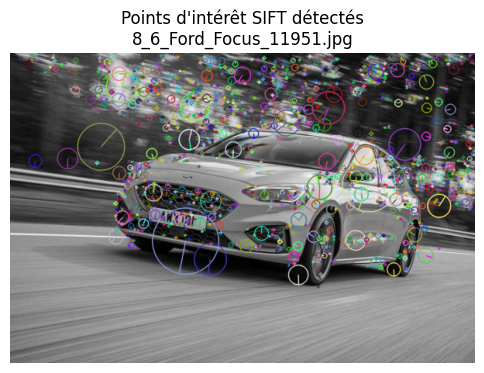

Extraction des descripteurs SIFT pour la base de données...


100%|██████████| 10000/10000 [02:07<00:00, 78.54it/s]


In [9]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt
from tqdm import tqdm

sift = cv2.SIFT_create()

example_query = QUERIES_GROUP_5[14]
example_path = os.path.join(DATA_DIR, example_query)
example_img = cv2.imread(example_path, cv2.IMREAD_GRAYSCALE)

if example_img is not None:
    keypoints, _ = sift.detectAndCompute(example_img, None)
    img_with_keypoints = cv2.drawKeypoints(example_img, keypoints, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

    plt.figure(figsize=(6, 6))
    plt.imshow(img_with_keypoints, cmap='gray')
    plt.title(f"Points d'intérêt SIFT détectés\n{example_query}")
    plt.axis('off')
    plt.show()

def extract_sift_descriptors(image_path, max_size=256):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None
        
    h, w = img.shape
    if max(h, w) > max_size:
        scale = max_size / max(h, w)
        img = cv2.resize(img, (int(w * scale), int(h * scale)))
        
    _, descriptors = sift.detectAndCompute(img, None)
    return descriptors

print("Extraction des descripteurs SIFT pour la base de données...")
db_sift_features = {}

for db_file in tqdm(all_images):
    db_path = os.path.join(DATA_DIR, db_file)
    des = extract_sift_descriptors(db_path)
    if des is not None:
        db_sift_features[db_file] = des

In [13]:
def extract_class_and_model(filename):
    basename = os.path.basename(filename)
    
    parts = basename.split('_')
    
    img_class = f"{parts[0]}_{parts[1]}"
    
    return img_class, parts

class_counts = {}

for db_file in all_images:
    db_class, _ = extract_class_and_model(db_file)
    class_counts[db_class] = class_counts.get(db_class, 0) + 1

print("Nombre d'images par classe dans la base :")
for cls, count in class_counts.items():
    print(f"Classe {cls} : {count} images")

Nombre d'images par classe dans la base :
Classe 0_0 : 100 images
Classe 0_1 : 162 images
Classe 0_2 : 139 images
Classe 0_3 : 100 images
Classe 0_4 : 100 images
Classe 0_5 : 100 images
Classe 0_6 : 100 images
Classe 0_7 : 99 images
Classe 0_8 : 100 images
Classe 1_0 : 100 images
Classe 1_1 : 100 images
Classe 1_2 : 118 images
Classe 1_3 : 100 images
Classe 1_4 : 100 images
Classe 1_5 : 86 images
Classe 1_6 : 100 images
Classe 1_7 : 96 images
Classe 1_8 : 100 images
Classe 1_9 : 100 images
Classe 2_0 : 100 images
Classe 2_1 : 100 images
Classe 2_2 : 100 images
Classe 2_3 : 100 images
Classe 2_4 : 100 images
Classe 2_5 : 100 images
Classe 2_6 : 100 images
Classe 2_7 : 100 images
Classe 2_8 : 100 images
Classe 2_9 : 100 images
Classe 3_0 : 100 images
Classe 3_1 : 100 images
Classe 3_2 : 100 images
Classe 3_3 : 100 images
Classe 3_4 : 86 images
Classe 3_5 : 100 images
Classe 3_6 : 100 images
Classe 3_7 : 100 images
Classe 3_8 : 114 images
Classe 3_9 : 100 images
Classe 4_0 : 136 images
Cl

In [14]:
import time

metrics_50 = {'P': [], 'R': [], 'AP': []}
metrics_100 = {'P': [], 'R': [], 'AP': []}
metrics_max = {'P': [], 'R': [], 'AP': []}
search_times = []

FLANN_INDEX_KDTREE = 1
index_params = dict(algorithm=FLANN_INDEX_KDTREE, trees=5)
search_params = dict(checks=50)
flann = cv2.FlannBasedMatcher(index_params, search_params)

print("=== DEBUT DE L'EVALUATION SIFT (GROUPE 05) ===")

for i, query in enumerate(QUERIES_GROUP_5):
    start_time = time.time()
    
    query_path = os.path.join(DATA_DIR, query)
    query_class, _ = extract_class_and_model(query)
    total_relevant = class_counts[query_class]
    
    query_des = extract_sift_descriptors(query_path)
    scores = [] 
    
    if query_des is not None and len(query_des) > 2:
        for db_file, db_des in db_sift_features.items():
            if db_des is None or len(db_des) < 2:
                continue
                
            try:
                matches = flann.knnMatch(query_des, db_des, k=2)
                
                good_matches = 0
                for m_n in matches:
                    if len(m_n) == 2:
                        m, n = m_n
                        if m.distance < 0.7 * n.distance:
                            good_matches += 1
                            
                db_class, _ = extract_class_and_model(db_file)
                scores.append((good_matches, db_class))
            except Exception:
                pass

    scores.sort(key=lambda x: x[0], reverse=True)
    retrieved_labels = [label for _, label in scores]
    
    search_times.append(time.time() - start_time)
    
    p_50, r_50, ap_50 = evaluate_query(retrieved_labels, query_class, total_relevant, k=50)
    metrics_50['P'].append(p_50)
    metrics_50['R'].append(r_50)
    metrics_50['AP'].append(ap_50)
    
    p_100, r_100, ap_100 = evaluate_query(retrieved_labels, query_class, total_relevant, k=100)
    metrics_100['P'].append(p_100)
    metrics_100['R'].append(r_100)
    metrics_100['AP'].append(ap_100)
    
    p_max, r_max, ap_max = evaluate_query(retrieved_labels, query_class, total_relevant, k=total_relevant)
    metrics_max['P'].append(p_max)
    metrics_max['R'].append(r_max)
    metrics_max['AP'].append(ap_max)
    
    print(f"Requête {i+1} | "
          f"P@50: {p_50*100:.1f}% | R@50: {r_50*100:.1f}% | AP@50: {ap_50*100:.1f}% | P@100: {p_100*100:.1f}% | R@100: {r_100*100:.1f}% | AP@100: {ap_100*100:.1f}% | P@Max: {p_max*100:.1f}% | R@Max: {r_max*100:.1f}% | AP@Max: {ap_max*100:.1f}%")

print("\n" + "=" * 40)
print("BILAN FINAL - DESCRIPTEUR SIFT")
print("=" * 40)
print(f"Temps de recherche moyen  : {np.mean(search_times)*1000:.2f} ms / image")

print("\n--- Performances @50 ---")
print(f"Precision moyenne (mP)    : {np.mean(metrics_50['P'])*100:.2f} %")
print(f"Recall moyen (mR)         : {np.mean(metrics_50['R'])*100:.2f} %")
print(f"Mean Avg Precision (mAP)  : {np.mean(metrics_50['AP'])*100:.2f} %")

print("\n--- Performances @100 ---")
print(f"Precision moyenne (mP)    : {np.mean(metrics_100['P'])*100:.2f} %")
print(f"Recall moyen (mR)         : {np.mean(metrics_100['R'])*100:.2f} %")
print(f"Mean Avg Precision (mAP)  : {np.mean(metrics_100['AP'])*100:.2f} %")

print("\n--- Performances @Max ---")
print(f"Precision moyenne (mP)    : {np.mean(metrics_max['P'])*100:.2f} %")
print(f"Recall moyen (mR)         : {np.mean(metrics_max['R'])*100:.2f} %")
print(f"Mean Avg Precision (mAP)  : {np.mean(metrics_max['AP'])*100:.2f} %")

=== DEBUT DE L'EVALUATION SIFT (GROUPE 05) ===
Requête 1 | P@50: 6.0% | R@50: 1.9% | AP@50: 5.5% | P@100: 8.0% | R@100: 4.9% | AP@100: 3.3% | P@Max: 4.9% | R@Max: 4.9% | AP@Max: 2.0%
Requête 2 | P@50: 4.0% | R@50: 2.0% | AP@50: 4.0% | P@100: 2.0% | R@100: 2.0% | AP@100: 2.0% | P@Max: 2.0% | R@Max: 2.0% | AP@Max: 2.0%
Requête 3 | P@50: 8.0% | R@50: 2.9% | AP@50: 2.5% | P@100: 4.0% | R@100: 2.9% | AP@100: 1.2% | P@Max: 3.6% | R@Max: 3.6% | AP@Max: 0.9%
Requête 4 | P@50: 4.0% | R@50: 2.0% | AP@50: 2.1% | P@100: 2.0% | R@100: 2.0% | AP@100: 1.1% | P@Max: 2.0% | R@Max: 2.0% | AP@Max: 1.1%
Requête 5 | P@50: 8.0% | R@50: 4.0% | AP@50: 4.4% | P@100: 5.0% | R@100: 5.0% | AP@100: 2.3% | P@Max: 5.0% | R@Max: 5.0% | AP@Max: 2.3%
Requête 6 | P@50: 10.0% | R@50: 5.0% | AP@50: 5.3% | P@100: 12.0% | R@100: 12.0% | AP@100: 3.4% | P@Max: 12.0% | R@Max: 12.0% | AP@Max: 3.4%
Requête 7 | P@50: 4.0% | R@50: 2.0% | AP@50: 4.0% | P@100: 5.0% | R@100: 5.0% | AP@100: 2.1% | P@Max: 5.0% | R@Max: 5.0% | AP@Max: 2